# 02 — EDA: Forex & Equity Panels

**Project:** GBP/USD direction prediction (2014–2024)  
**Goal:** Understand the forex and equity panels; define and analyse the prediction target.

Panels analysed:
- `forex_panel.csv` — 13 currency pairs × 4 OHLC cols = 52 columns, 2870 rows
- `equity_panel.csv` — 9 equity indices × 6 cols (OHLCV + sqrt_vol) = 54 columns, 2870 rows

Sections:
1. Load & overview
2. Target variable — GBP/USD direction
3. GBP/USD price series & returns
4. OHLC spread (intraday range) analysis
5. Forex pairs — close-price returns distribution
6. Forex pairs — correlation matrix
7. Equity indices — price series & returns
8. Equity volume & sqrt-volume
9. Equity–forex cross-correlation
10. Rolling volatility (GBP/USD 30-day)
11. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/interim/'

# Pairs and indices
FX_PAIRS = ['AUD_USD','EUR_USD','EUR_GBP','GBP_AUD','GBP_CAD',
            'GBP_CHF','GBP_JPY','GBP_NZD','GBP_USD',
            'NZD_USD','USD_CAD','USD_CHF','USD_JPY']

EQ_INDICES = ['USA_SP500','USA_NASDAQ_COMPOSITE','USA_NASDAQ100',
              'USA_RUSSELL2000','USA_DJI',
              'UK_FTSE100','UK_FTSE250','UK_FTSE350','UK_FTSE_ALL_SHARE']

TARGET_PAIR = 'GBP_USD'

## 1. Load & Overview

In [2]:
forex  = pd.read_csv(DATA + 'forex_panel.csv',  index_col=0, parse_dates=True)
equity = pd.read_csv(DATA + 'equity_panel.csv', index_col=0, parse_dates=True)

for name, df in [('Forex', forex), ('Equity', equity)]:
    print(f'--- {name} panel ---')
    print(f'  Shape : {df.shape}')
    print(f'  Range : {df.index[0].date()} → {df.index[-1].date()}')
    nan_total = df.isna().sum().sum()
    print(f'  NaN   : {nan_total} ({nan_total / df.size * 100:.2f}%)')
    print()

--- Forex panel ---
  Shape : (2870, 52)
  Range : 2014-01-01 → 2024-12-31
  NaN   : 0 (0.00%)

--- Equity panel ---
  Shape : (2870, 54)
  Range : 2014-01-01 → 2024-12-31
  NaN   : 54 (0.03%)



In [3]:
# NaN detail — equity has 1 row on 2014-01-01 (New Year's Day, no trading)
nan_rows = equity[equity.isna().any(axis=1)]
print(f'Equity NaN rows: {len(nan_rows)}')
if len(nan_rows) > 0:
    print(nan_rows.index.tolist())
    print('(This row will be dropped when building the final ML dataset)')

Equity NaN rows: 1
[Timestamp('2014-01-01 00:00:00')]
(This row will be dropped when building the final ML dataset)


## 2. Target Variable — GBP/USD Direction

```
direction(t) = 1  if close(t+1) > close(t)   # price goes UP next day
direction(t) = 0  if close(t+1) <= close(t)
```

Note: we use `shift(-1)` — the label at row t is the movement of the *next* day's close.

In [4]:
gbp_close = forex['GBP_USD_close']
direction = (gbp_close.shift(-1) > gbp_close).astype(float)
direction.name = 'direction'

# Drop last row (NaN target — no t+1 available)
direction = direction.iloc[:-1]

vc = direction.value_counts().sort_index()
total = len(direction)
up_pct   = vc[1] / total * 100
down_pct = vc[0] / total * 100

print('=== Target distribution ===')
print(f'UP   (1): {int(vc[1]):>5}  ({up_pct:.1f}%)')
print(f'DOWN (0): {int(vc[0]):>5}  ({down_pct:.1f}%)')
print(f'Total   : {total}')
print()
print(f'Class imbalance ratio: {max(up_pct, down_pct) / min(up_pct, down_pct):.2f}x')
if abs(up_pct - 50) < 5:
    print('=> Well-balanced dataset — no SMOTE / class-weight correction needed')
else:
    print('=> Imbalanced — consider class_weight or SMOTE in modelling')

=== Target distribution ===
UP   (1):  1408  (49.1%)
DOWN (0):  1461  (50.9%)
Total   : 2869

Class imbalance ratio: 1.04x
=> Well-balanced dataset — no SMOTE / class-weight correction needed


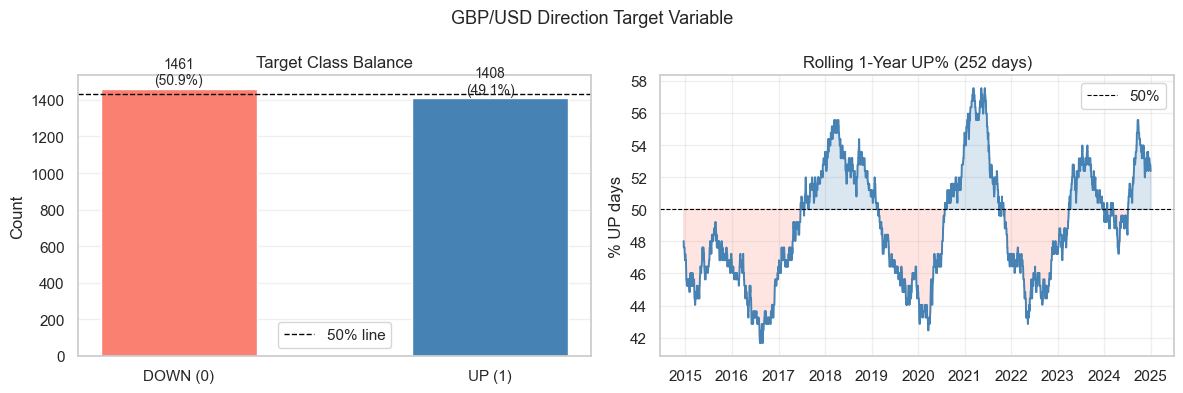

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['DOWN (0)', 'UP (1)'], [vc[0], vc[1]],
                   color=['salmon', 'steelblue'], edgecolor='white', width=0.5)
axes[0].axhline(total / 2, color='black', lw=1, ls='--', label='50% line')
for bar, count, pct in zip(bars, [vc[0], vc[1]], [down_pct, up_pct]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Target Class Balance')
axes[0].set_ylabel('Count')
axes[0].legend()

# Rolling UP% (252-day window ≈ 1 year)
rolling_up = direction.rolling(252).mean() * 100
axes[1].plot(rolling_up.index, rolling_up, color='steelblue', lw=1.4)
axes[1].axhline(50, color='black', lw=0.8, ls='--', label='50%')
axes[1].fill_between(rolling_up.index, rolling_up, 50,
                     where=(rolling_up > 50), alpha=0.2, color='steelblue')
axes[1].fill_between(rolling_up.index, rolling_up, 50,
                     where=(rolling_up < 50), alpha=0.2, color='salmon')
axes[1].set_title('Rolling 1-Year UP% (252 days)')
axes[1].set_ylabel('% UP days')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].legend()

plt.suptitle('GBP/USD Direction Target Variable', fontsize=13)
plt.tight_layout()
plt.show()

## 3. GBP/USD Price Series & Returns

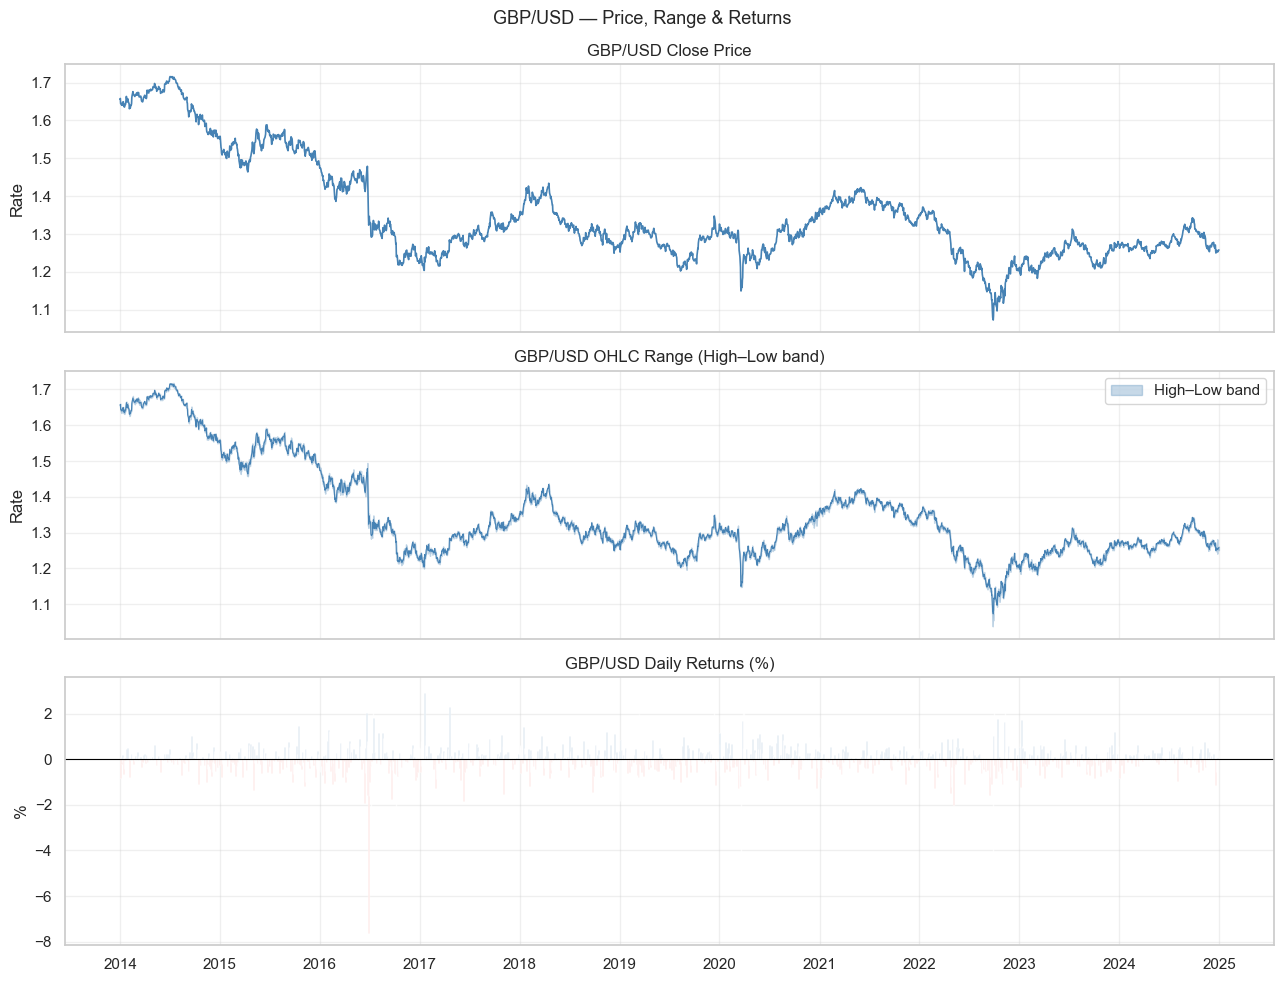

In [6]:
gbp_ohlc = forex[['GBP_USD_open','GBP_USD_high','GBP_USD_low','GBP_USD_close']]
gbp_ret  = gbp_close.pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Close price
axes[0].plot(gbp_close.index, gbp_close, color='steelblue', lw=1.2)
axes[0].set_title('GBP/USD Close Price')
axes[0].set_ylabel('Rate')

# OHLC high-low band
axes[1].fill_between(gbp_ohlc.index, gbp_ohlc['GBP_USD_low'], gbp_ohlc['GBP_USD_high'],
                     alpha=0.3, color='steelblue', label='High–Low band')
axes[1].plot(gbp_ohlc.index, gbp_ohlc['GBP_USD_close'], color='steelblue', lw=0.8)
axes[1].set_title('GBP/USD OHLC Range (High–Low band)')
axes[1].set_ylabel('Rate')
axes[1].legend()

# Daily returns
axes[2].bar(gbp_ret.index, gbp_ret * 100,
            color=np.where(gbp_ret >= 0, 'steelblue', 'salmon'), width=1, alpha=0.7)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('GBP/USD Daily Returns (%)')
axes[2].set_ylabel('%')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('GBP/USD — Price, Range & Returns', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Returns statistics
stats = gbp_ret.describe()
print('GBP/USD daily return statistics:')
print(stats.to_string())
print(f'\nSkewness : {gbp_ret.skew():.4f}')
print(f'Kurtosis : {gbp_ret.kurt():.4f}  (normal=0, fat tails > 0)')

GBP/USD daily return statistics:
count    2869.000000
mean       -0.000080
std         0.005696
min        -0.076038
25%        -0.002999
50%        -0.000064
75%         0.002974
max         0.030772

Skewness : -0.9120
Kurtosis : 14.4381  (normal=0, fat tails > 0)


## 4. OHLC Spread (Intraday Range) Analysis

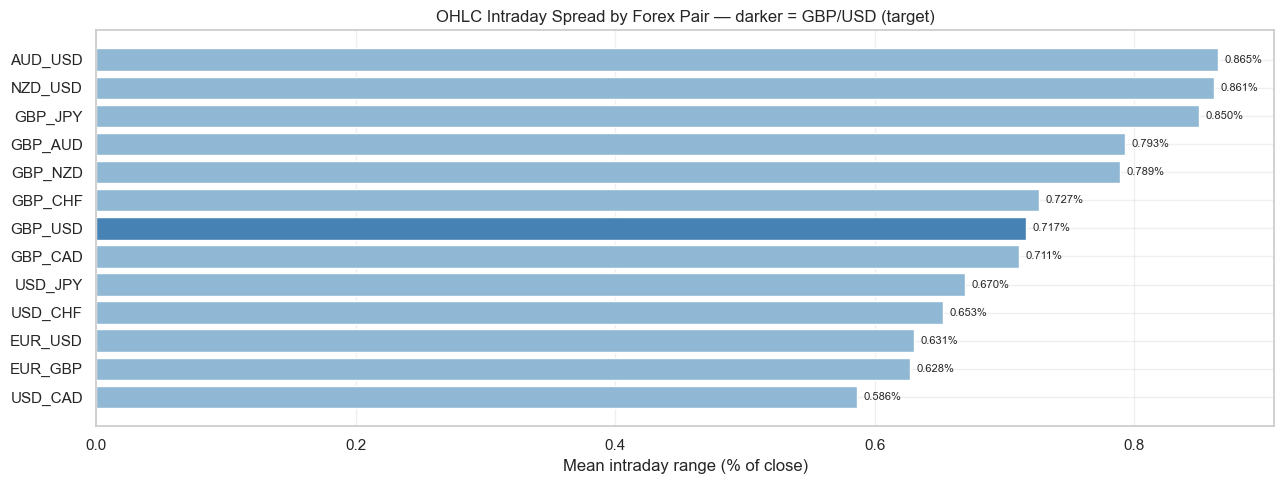

In [8]:
# Intraday range as % of close
spreads = {}
for pair in FX_PAIRS:
    hi = forex[f'{pair}_high']
    lo = forex[f'{pair}_low']
    cl = forex[f'{pair}_close']
    spreads[pair] = ((hi - lo) / cl * 100).dropna()

spread_df = pd.DataFrame({k: v.mean() for k, v in spreads.items()}, index=['mean_spread_%'])
spread_df = spread_df.T.sort_values('mean_spread_%', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['steelblue' if p == 'GBP_USD' else '#90b8d4' for p in spread_df.index]
bars = ax.barh(spread_df.index, spread_df['mean_spread_%'], color=colors, edgecolor='white')
ax.set_xlabel('Mean intraday range (% of close)')
ax.set_title('OHLC Intraday Spread by Forex Pair — darker = GBP/USD (target)')
ax.invert_yaxis()
for bar, val in zip(bars, spread_df['mean_spread_%']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Forex Pairs — Returns Distribution

In [9]:
returns = pd.DataFrame({
    pair: forex[f'{pair}_close'].pct_change() * 100
    for pair in FX_PAIRS
}).dropna()

# Summary stats
ret_stats = returns.describe().T[['mean','std','min','max']]
ret_stats['skew'] = returns.skew()
ret_stats['kurt'] = returns.kurt()
ret_stats = ret_stats.round(4)
print('Forex daily return summary:')
print(ret_stats.to_string())

Forex daily return summary:
           mean     std      min      max    skew      kurt
AUD_USD -0.0105  0.6284  -3.1682   2.8944 -0.0526    1.2659
EUR_USD -0.0084  0.4885  -2.7752   2.8545 -0.0233    2.6608
EUR_GBP  0.0015  0.5627 -10.4617  11.6407  1.3310  109.1605
GBP_AUD  0.0046  0.5689  -6.3281   2.9985 -0.3884    6.4339
GBP_CAD  0.0025  0.5349  -6.2163   3.4391 -0.4641    9.0373
GBP_CHF -0.0072  0.6234 -16.4476   2.9729 -6.7712  173.4786
GBP_JPY  0.0069  0.6860 -10.0425   4.5178 -1.1401   18.6473
GBP_NZD  0.0053  0.5905  -6.1638   3.2508 -0.2289    5.8971
GBP_USD -0.0080  0.5696  -7.6038   3.0772 -0.9120   14.4381
NZD_USD -0.0111  0.6492  -3.6745   2.8699 -0.0606    1.1315
USD_CAD  0.0117  0.4538  -3.1434   3.0138 -0.0182    2.5429
USD_CHF  0.0020  0.5666 -16.1473   2.5017 -8.1666  230.2678
USD_JPY  0.0157  0.5549  -3.7250   3.3220 -0.2204    3.6079


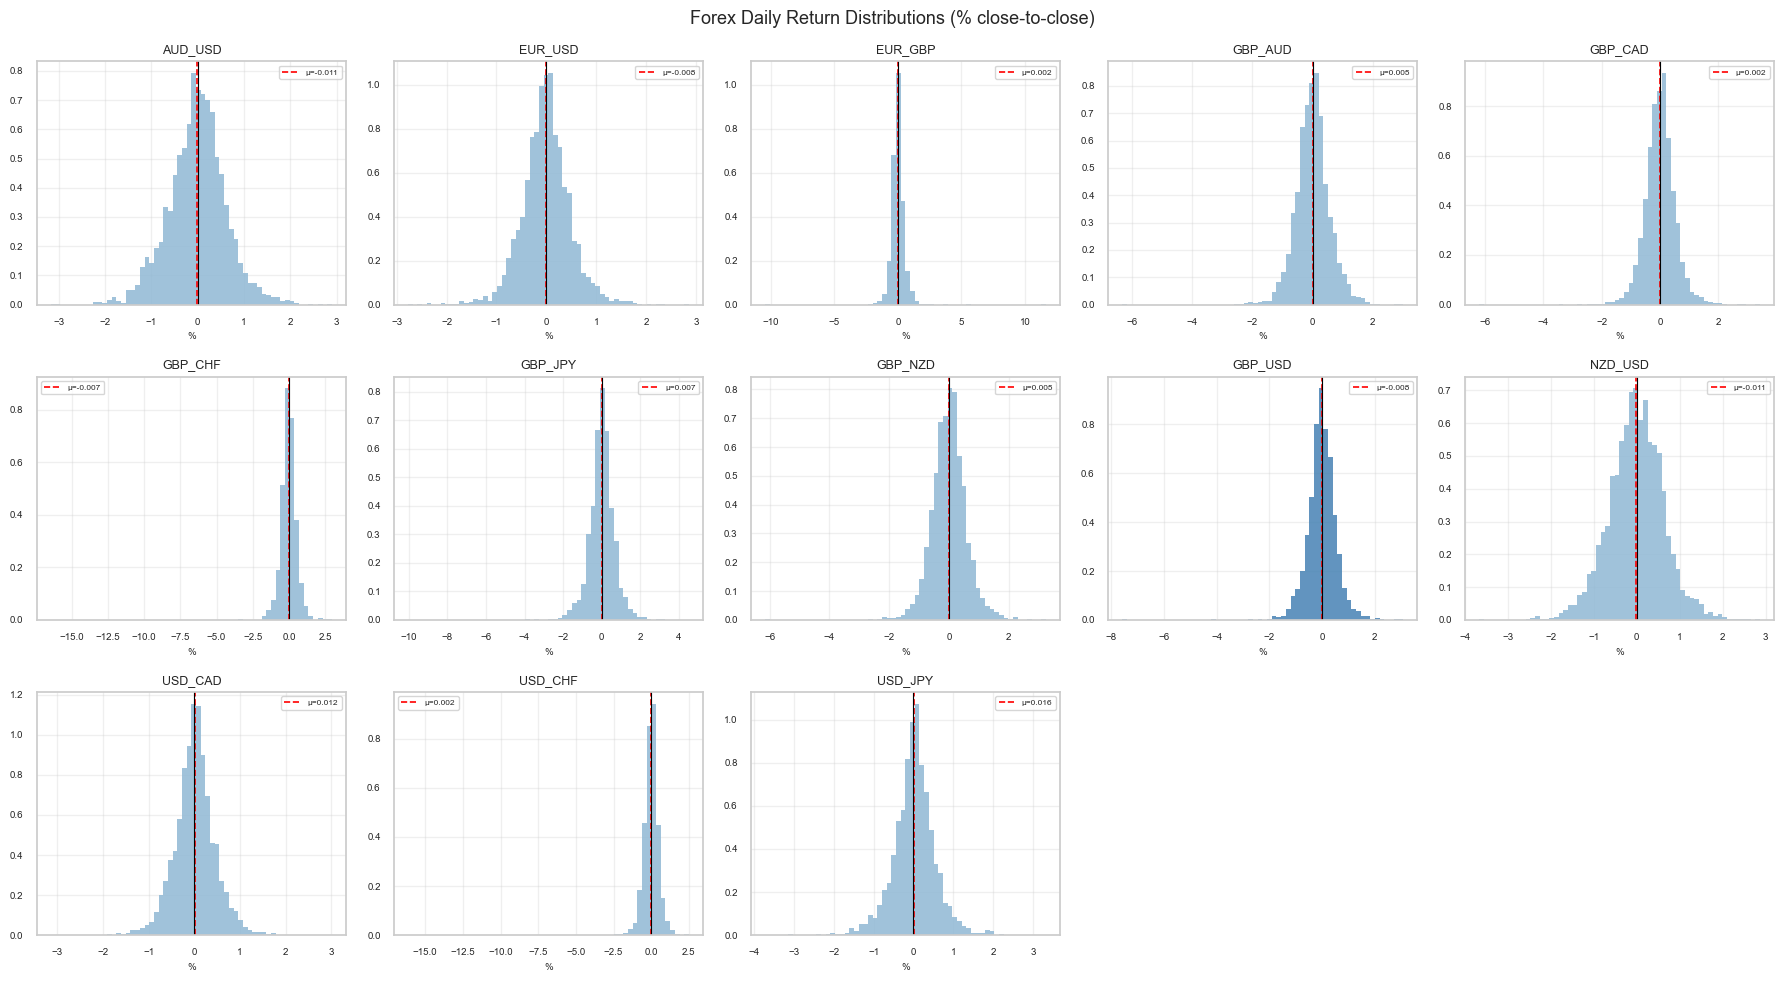

In [10]:
# Distribution grid
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for ax, pair in zip(axes, FX_PAIRS):
    data = returns[pair].dropna()
    color = 'steelblue' if pair == 'GBP_USD' else '#90b8d4'
    ax.hist(data, bins=60, color=color, edgecolor='none', alpha=0.85, density=True)
    ax.axvline(data.mean(), color='red',   lw=1.2, ls='--', label=f'μ={data.mean():.3f}')
    ax.axvline(0,           color='black', lw=0.8)
    ax.set_title(pair, fontsize=9)
    ax.set_xlabel('%', fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

for ax in axes[len(FX_PAIRS):]:
    ax.set_visible(False)

plt.suptitle('Forex Daily Return Distributions (% close-to-close)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Forex Pairs — Correlation Matrix (Daily Returns)

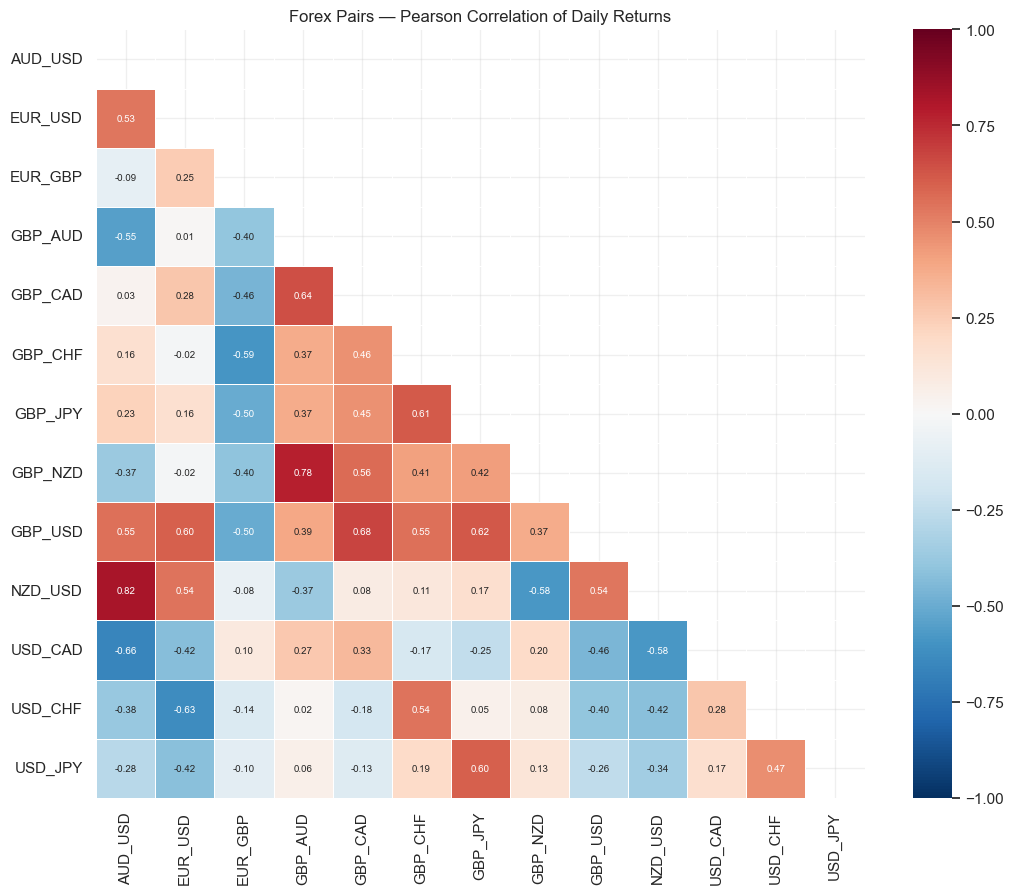

Highly correlated pairs (|r| > 0.7):
  AUD_USD ↔ NZD_USD: 0.821
  GBP_AUD ↔ GBP_NZD: 0.780


In [11]:
corr_fx = returns.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_fx, dtype=bool))
sns.heatmap(corr_fx, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Forex Pairs — Pearson Correlation of Daily Returns', fontsize=12)
plt.tight_layout()
plt.show()

# High correlation pairs (|r| > 0.7) excluding self-correlation
print('Highly correlated pairs (|r| > 0.7):')
for i in range(len(corr_fx.columns)):
    for j in range(i+1, len(corr_fx.columns)):
        r = corr_fx.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr_fx.columns[i]} ↔ {corr_fx.columns[j]}: {r:.3f}')

## 7. Equity Indices — Price Series & Returns

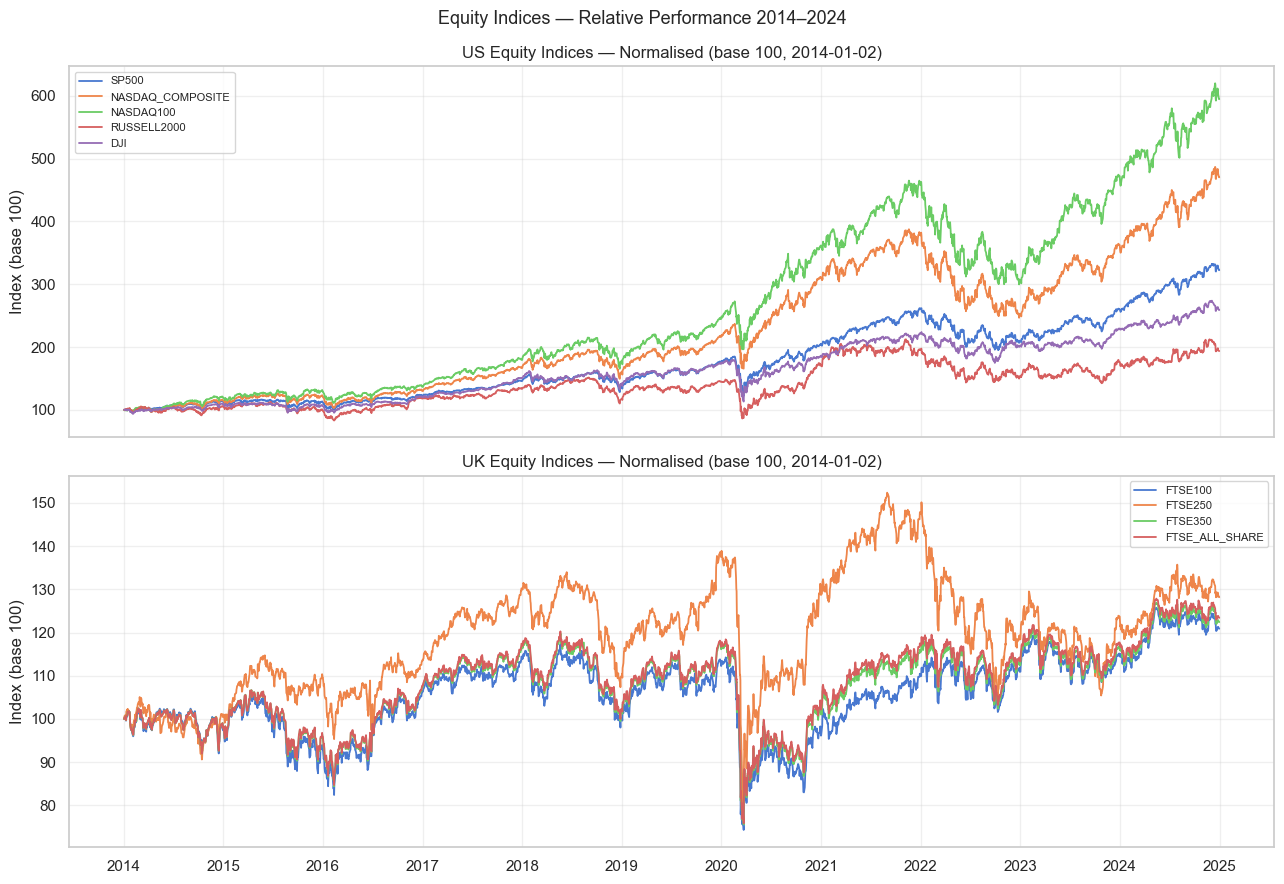

In [12]:
# Normalised price (base 100 at 2014-01-02 — first trading day)
eq_close = equity[[f'{idx}_close' for idx in EQ_INDICES]].copy()
eq_close.columns = EQ_INDICES

first_valid = eq_close.dropna().index[0]
eq_norm = eq_close / eq_close.loc[first_valid] * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# US indices
us_cols = [c for c in EQ_INDICES if c.startswith('USA')]
for col in us_cols:
    axes[0].plot(eq_norm.index, eq_norm[col], lw=1.3, label=col.replace('USA_',''))
axes[0].set_title('US Equity Indices — Normalised (base 100, 2014-01-02)')
axes[0].set_ylabel('Index (base 100)')
axes[0].legend(fontsize=8)

# UK indices
uk_cols = [c for c in EQ_INDICES if c.startswith('UK')]
for col in uk_cols:
    axes[1].plot(eq_norm.index, eq_norm[col], lw=1.3, label=col.replace('UK_',''))
axes[1].set_title('UK Equity Indices — Normalised (base 100, 2014-01-02)')
axes[1].set_ylabel('Index (base 100)')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Equity Indices — Relative Performance 2014–2024', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Equity returns
eq_ret = eq_close.pct_change() * 100

ret_stats_eq = eq_ret.describe().T[['mean','std','min','max']]
ret_stats_eq['skew'] = eq_ret.skew()
ret_stats_eq['kurt'] = eq_ret.kurt()
ret_stats_eq.columns.name = None
print('Equity daily return summary:')
print(ret_stats_eq.round(4).to_string())

Equity daily return summary:
                        mean     std      min      max    skew     kurt
USA_SP500             0.0466  1.0726 -11.9841   9.3828 -0.5374  15.6073
USA_NASDAQ_COMPOSITE  0.0623  1.2859 -12.3213   9.3460 -0.4593   7.8879
USA_NASDAQ100         0.0710  1.3265 -12.1932  10.0722 -0.3559   7.2378
USA_RUSSELL2000       0.0327  1.3856 -14.2720   9.3915 -0.6148  10.1103
USA_DJI               0.0388  1.0541 -12.9265  11.3650 -0.5645  22.5991
UK_FTSE100            0.0111  0.9434 -10.8738   9.0530 -0.6150  13.4231
UK_FTSE250            0.0137  1.0032  -9.3534  10.4247 -0.1288  14.1028
UK_FTSE350            0.0113  0.9252 -10.6065   8.9473 -0.5975  13.8780
UK_FTSE_ALL_SHARE     0.0115  0.9146 -10.4914   8.8612 -0.6043  14.0263


## 8. Equity Volume & sqrt-Volume

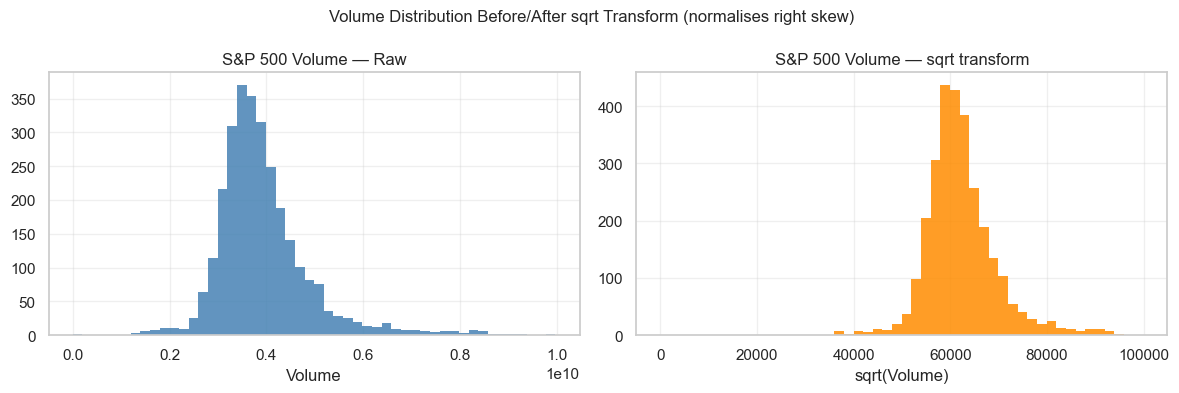

Raw volume  skew: 1.66
Sqrt volume skew: 0.76


In [14]:
# Compare raw volume vs sqrt-volume distribution for S&P 500
vol_raw  = equity['USA_SP500_volume'].dropna()
vol_sqrt = equity['USA_SP500_volume_sqrt'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vol_raw, bins=50, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title('S&P 500 Volume — Raw')
axes[0].set_xlabel('Volume')

axes[1].hist(vol_sqrt, bins=50, color='darkorange', edgecolor='none', alpha=0.85)
axes[1].set_title('S&P 500 Volume — sqrt transform')
axes[1].set_xlabel('sqrt(Volume)')

plt.suptitle('Volume Distribution Before/After sqrt Transform (normalises right skew)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Raw volume  skew: {vol_raw.skew():.2f}')
print(f'Sqrt volume skew: {vol_sqrt.skew():.2f}')

## 9. Equity–Forex Cross-Correlation

GBP/USD daily returns vs each equity index daily return.

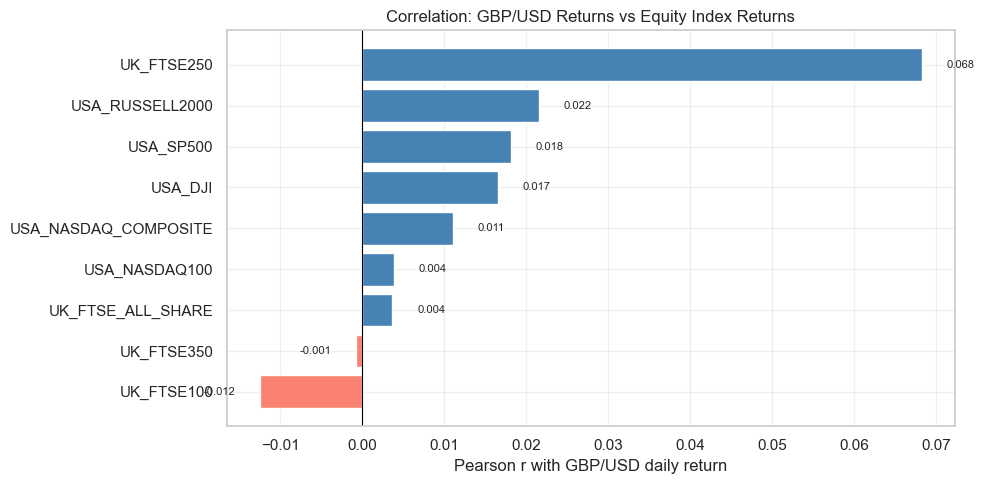

In [15]:
gbp_ret_s = returns['GBP_USD']

cross_corr = {}
for idx in EQ_INDICES:
    eq_r = eq_ret[idx].dropna()
    aligned = pd.concat([gbp_ret_s, eq_r], axis=1).dropna()
    r = aligned.corr().iloc[0, 1]
    cross_corr[idx] = r

cross_df = pd.Series(cross_corr).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in cross_df]
ax.barh(cross_df.index, cross_df, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r with GBP/USD daily return')
ax.set_title('Correlation: GBP/USD Returns vs Equity Index Returns')
for i, (idx, val) in enumerate(cross_df.items()):
    ax.text(val + (0.003 if val >= 0 else -0.003), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Rolling Volatility — GBP/USD 30-day

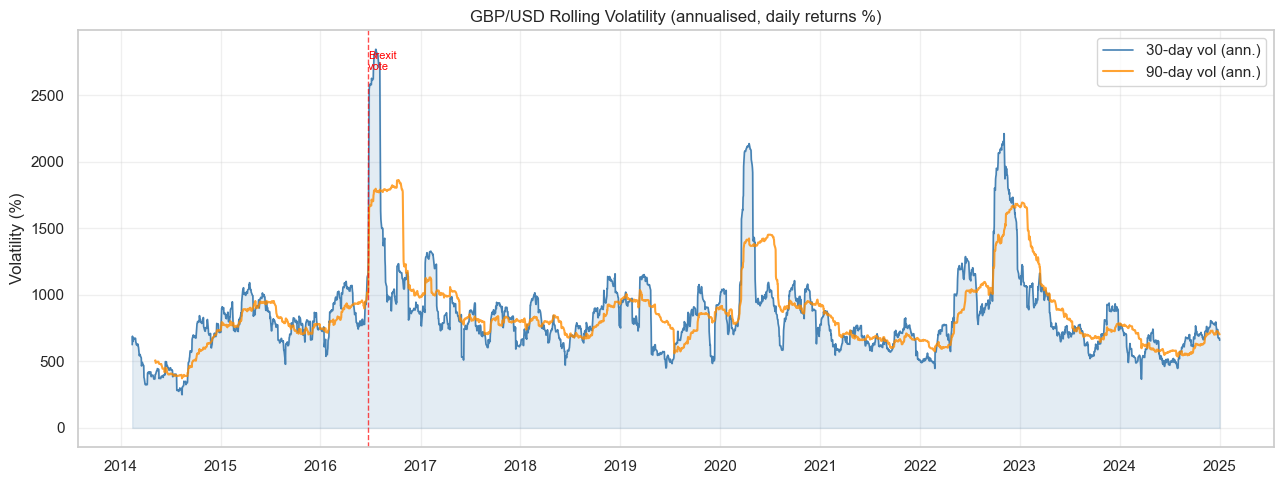

Mean 30d vol (ann.): 842.23%
Peak 30d vol (ann.): 2842.98% on 2016-07-22


In [16]:
gbp_vol_30 = gbp_ret_s.rolling(30).std() * np.sqrt(252)  # annualised
gbp_vol_90 = gbp_ret_s.rolling(90).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(gbp_vol_30.index, gbp_vol_30 * 100, lw=1.2, color='steelblue',  label='30-day vol (ann.)')
ax.plot(gbp_vol_90.index, gbp_vol_90 * 100, lw=1.5, color='darkorange', label='90-day vol (ann.)', alpha=0.8)
ax.fill_between(gbp_vol_30.index, gbp_vol_30 * 100, alpha=0.15, color='steelblue')

# Annotate Brexit spike
brexit = pd.Timestamp('2016-06-24')
ax.axvline(brexit, color='red', lw=1, ls='--', alpha=0.7)
ax.text(brexit, ax.get_ylim()[1] * 0.9, 'Brexit\nvote', color='red', fontsize=8, ha='left')

ax.set_title('GBP/USD Rolling Volatility (annualised, daily returns %)')
ax.set_ylabel('Volatility (%)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f'Mean 30d vol (ann.): {gbp_vol_30.mean()*100:.2f}%')
print(f'Peak 30d vol (ann.): {gbp_vol_30.max()*100:.2f}% on {gbp_vol_30.idxmax().date()}')

## 11. Key Takeaways

_(Fill in after running the cells above)_

### Target variable
- Class balance: ~49% UP / ~51% DOWN → well-balanced, no SMOTE needed
- Rolling UP% fluctuates around 50% through the decade
- …

### GBP/USD price & returns
- …

### Forex correlation structure
- Highly correlated pairs: …
- GBP-pairs tend to move together → risk of multicollinearity in features

### Equity–forex link
- …

### Volume
- sqrt transform successfully reduces right skew: skew(raw) >> skew(sqrt)

### Volatility regime
- Spike around Brexit 2016-06-24
- …

### Implications for feature engineering (Goal 3)
- High-correlation forex pairs → consider dropping one from each cluster  
- Rolling volatility is a candidate engineered feature  
- OHLC intraday range → candidate feature for regime detection